In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import torch
from models.linear_probes import linear_probe, linear_probe_tuned
from models.feature_generation import build_feature_bank, extract_encoder, extract_feature,pool_features
from preprocessing.dataset import PipistrelleDataset
from evaluation.metrics import compute_cv_stats,plot_model_comparison,label_confusion
import pandas as pd
from sklearn.metrics import average_precision_score
from evaluation.metrics import compute_metrics,compile_results,generate_metrics_table2
from evaluation.metrics import plot_comprehensive_calibration
from models.MLP_balancing import balancing_mlp
import pickle
from pathlib import Path
import os


c:\Users\artem\AppData\Local\miniconda3\envs\playground\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\artem\AppData\Local\miniconda3\envs\playground\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)
c:\Users\artem\AppData\Local\m

In [3]:
print(torch.cuda.is_available())

True


In [4]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Is built with CUDA: ", tf.test.is_built_with_cuda())


Num GPUs Available:  0
Is built with CUDA:  False


In [6]:
echo_filter = True
overlap = 0.5

dir = Path(os.getcwd()).resolve().parent / "data" 
for i,encoder in enumerate(["effnetb0","perch2","NLM_BEATs"]):
    print(f"Testing encoder: {encoder}")
    encoder_model = extract_encoder(encoder, device='cpu')
    batdata = PipistrelleDataset(data_input=str(dir / "bat_metadata.csv"),
                                root_dir=str(dir / "xenocanto-dataset"),
                                encoder = encoder,
                                filter_echo=echo_filter,
                                overlap=overlap)
    preprocessed_audio,labels = batdata[i]
    print(f"Shape of preprocessed audio : {preprocessed_audio.shape}")
    encoded_window = extract_feature(preprocessed_audio[i], encoder_model, encoder, device='cpu')
    print(f"Shape of encoder features : {encoded_window.shape}")
    #features,labels = build_feature_bank(batdata, encoder_model, encoder, device='cpu')

Testing encoder: effnetb0
Shape of preprocessed audio : torch.Size([104, 160000])
Shape of encoder features : torch.Size([1, 1280, 4, 32])
Testing encoder: perch2
Shape of preprocessed audio : torch.Size([3, 160000])


InvalidArgumentError: Graph execution error:

Detected at node XlaCallModule defined at (most recent call last):
<stack traces unavailable>
Error refining argument shapes: UNKNOWN: <unknown>:0: error: 'func.func' op invalid refinement for argument 497, refinement rank must match operand rank in tensor<?x160000xf32> -> tensor<160000xf32>
<unknown>:0: note: see current operation: 
"func.func"() <{arg_attrs = [{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {

In [ ]:
dir = Path(os.getcwd()).resolve().parent / "data" 
for encoder in ["effnetb0","perch2","NLM_BEATs"]:
    print(f"Testing encoder: {encoder}")
    encoder_model = extract_encoder(encoder)
    batdata = PipistrelleDataset(data_input=str(dir / "bat_metadata.csv"),
                                root_dir=str(dir / "xenocanto-dataset"),
                                encoder = encoder)
    print("bat data extraction")
    windows1,labels1 = batdata[0]
    windows2,labels2= batdata[1]
    print("bat data extraction succsessful")

    label_list = []
    label_list.append(labels1.numpy())
    label_list.append(labels2.numpy())

    feature_list = []
    feats1 = extract_feature(windows1, encoder_model, encoder, device='cpu')
    print(f"Shape of encoder features : {feats1.shape}")
    feature_list.append(feats1.numpy())
    feats2 = extract_feature(windows2, encoder_model, encoder, device='cpu')
    print(f"Shape of encoder features : {feats2.shape}")
    feature_list.append(feats2.numpy())

    pool = pool_features(feature_list, windows=True, method='mean',encoder=encoder)
    print(f"Shape of pooled features over windows : {pool.shape}")

    pool2 = pool_features(feature_list, windows=False, window_pooled=False, method='mean',encoder=encoder)
    print(f"Shape of pooled features over patches : {pool2[0].shape}, {pool2[1].shape}")

    pool3 = pool_features(pool, windows=False, window_pooled=True, method='mean',encoder=encoder)
    print(f"Shape of pooled features over patches after window pooling: {pool3.shape}")



In [91]:
dir = Path(os.getcwd()).resolve().parent 
path = str(dir / "models" / "features")
X_eff0 = np.load(path + "\\X_features2_not_normalized.npy")
X_NLM = np.load(path + "\\X_features_NLM.npy")
X_per2 = np.load(path + "\\perch_features.npz")['features']
y = np.load(path + "\\Y_labels2_not_normalized.npy")
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

In [4]:
print(X_eff0.shape, X_NLM.shape, X_per2.shape, y.shape)

(284, 1280, 4, 32) (284, 496, 768) (284, 1536) (284, 5)


In [92]:
#pooled features
X_eff0_pooled = pool_features(X_eff0, windows=False, window_pooled=True, method='mean',encoder="effnetb0")
X_NLM_pooled = pool_features(X_NLM, windows=False, window_pooled=True, method='mean',encoder="NLM_BEATs")
X_per2_pooled = X_per2

In [106]:
eff0_all_results = linear_probe_tuned(X_eff0_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3

In [107]:
NLM_all_results =linear_probe_tuned(X_NLM_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3

In [112]:
per2_all_results =linear_probe_tuned(X_per2_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3

In [26]:
#testing linear probe of effnetb0 
X_eff0_pooled = pool_features(X_eff0, windows=False, window_pooled=True, method='mean',encoder="effnetb0")
all_results = linear_probe_tuned(X_eff0_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3

In [ ]:
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']

eff0_results = compile_results(eff0_all_results,label_names=label_names,encoder="eff")
NLM_results = compile_results(NLM_all_results,label_names=label_names,encoder="NLM")
per2_results = compile_results(per2_all_results,label_names=label_names,encoder="per2")

results = eff0_results | NLM_results | per2_results
#print(pd.DataFrame(results))
print(generate_metrics_table2(results,label_names=label_names)[0])

                      Model      Macro-AUC Macro-AP (cmAP)  Brier Score ↓  \
0                   eff SVM  0.918 ± 0.007   0.812 ± 0.015  0.067 ± 0.003   
1         eff Random Forest  0.919 ± 0.003   0.805 ± 0.016  0.080 ± 0.001   
2                   eff MLP  0.920 ± 0.006   0.809 ± 0.012  0.073 ± 0.003   
3    eff Prevalence guesser  0.508 ± 0.041   0.377 ± 0.022  0.160 ± 0.005   
4                   NLM SVM  0.918 ± 0.008   0.852 ± 0.006  0.061 ± 0.001   
5         NLM Random Forest  0.914 ± 0.004   0.818 ± 0.008  0.081 ± 0.002   
6                   NLM MLP  0.924 ± 0.008   0.842 ± 0.009  0.068 ± 0.006   
7    NLM Prevalence guesser  0.505 ± 0.013   0.376 ± 0.013  0.161 ± 0.003   
8                  per2 SVM  0.934 ± 0.005   0.844 ± 0.008  0.059 ± 0.002   
9        per2 Random Forest  0.920 ± 0.005   0.826 ± 0.010  0.073 ± 0.001   
10                 per2 MLP  0.946 ± 0.008   0.877 ± 0.013  0.060 ± 0.004   
11  per2 Prevalence guesser  0.519 ± 0.030   0.382 ± 0.016  0.159 ± 0.005   

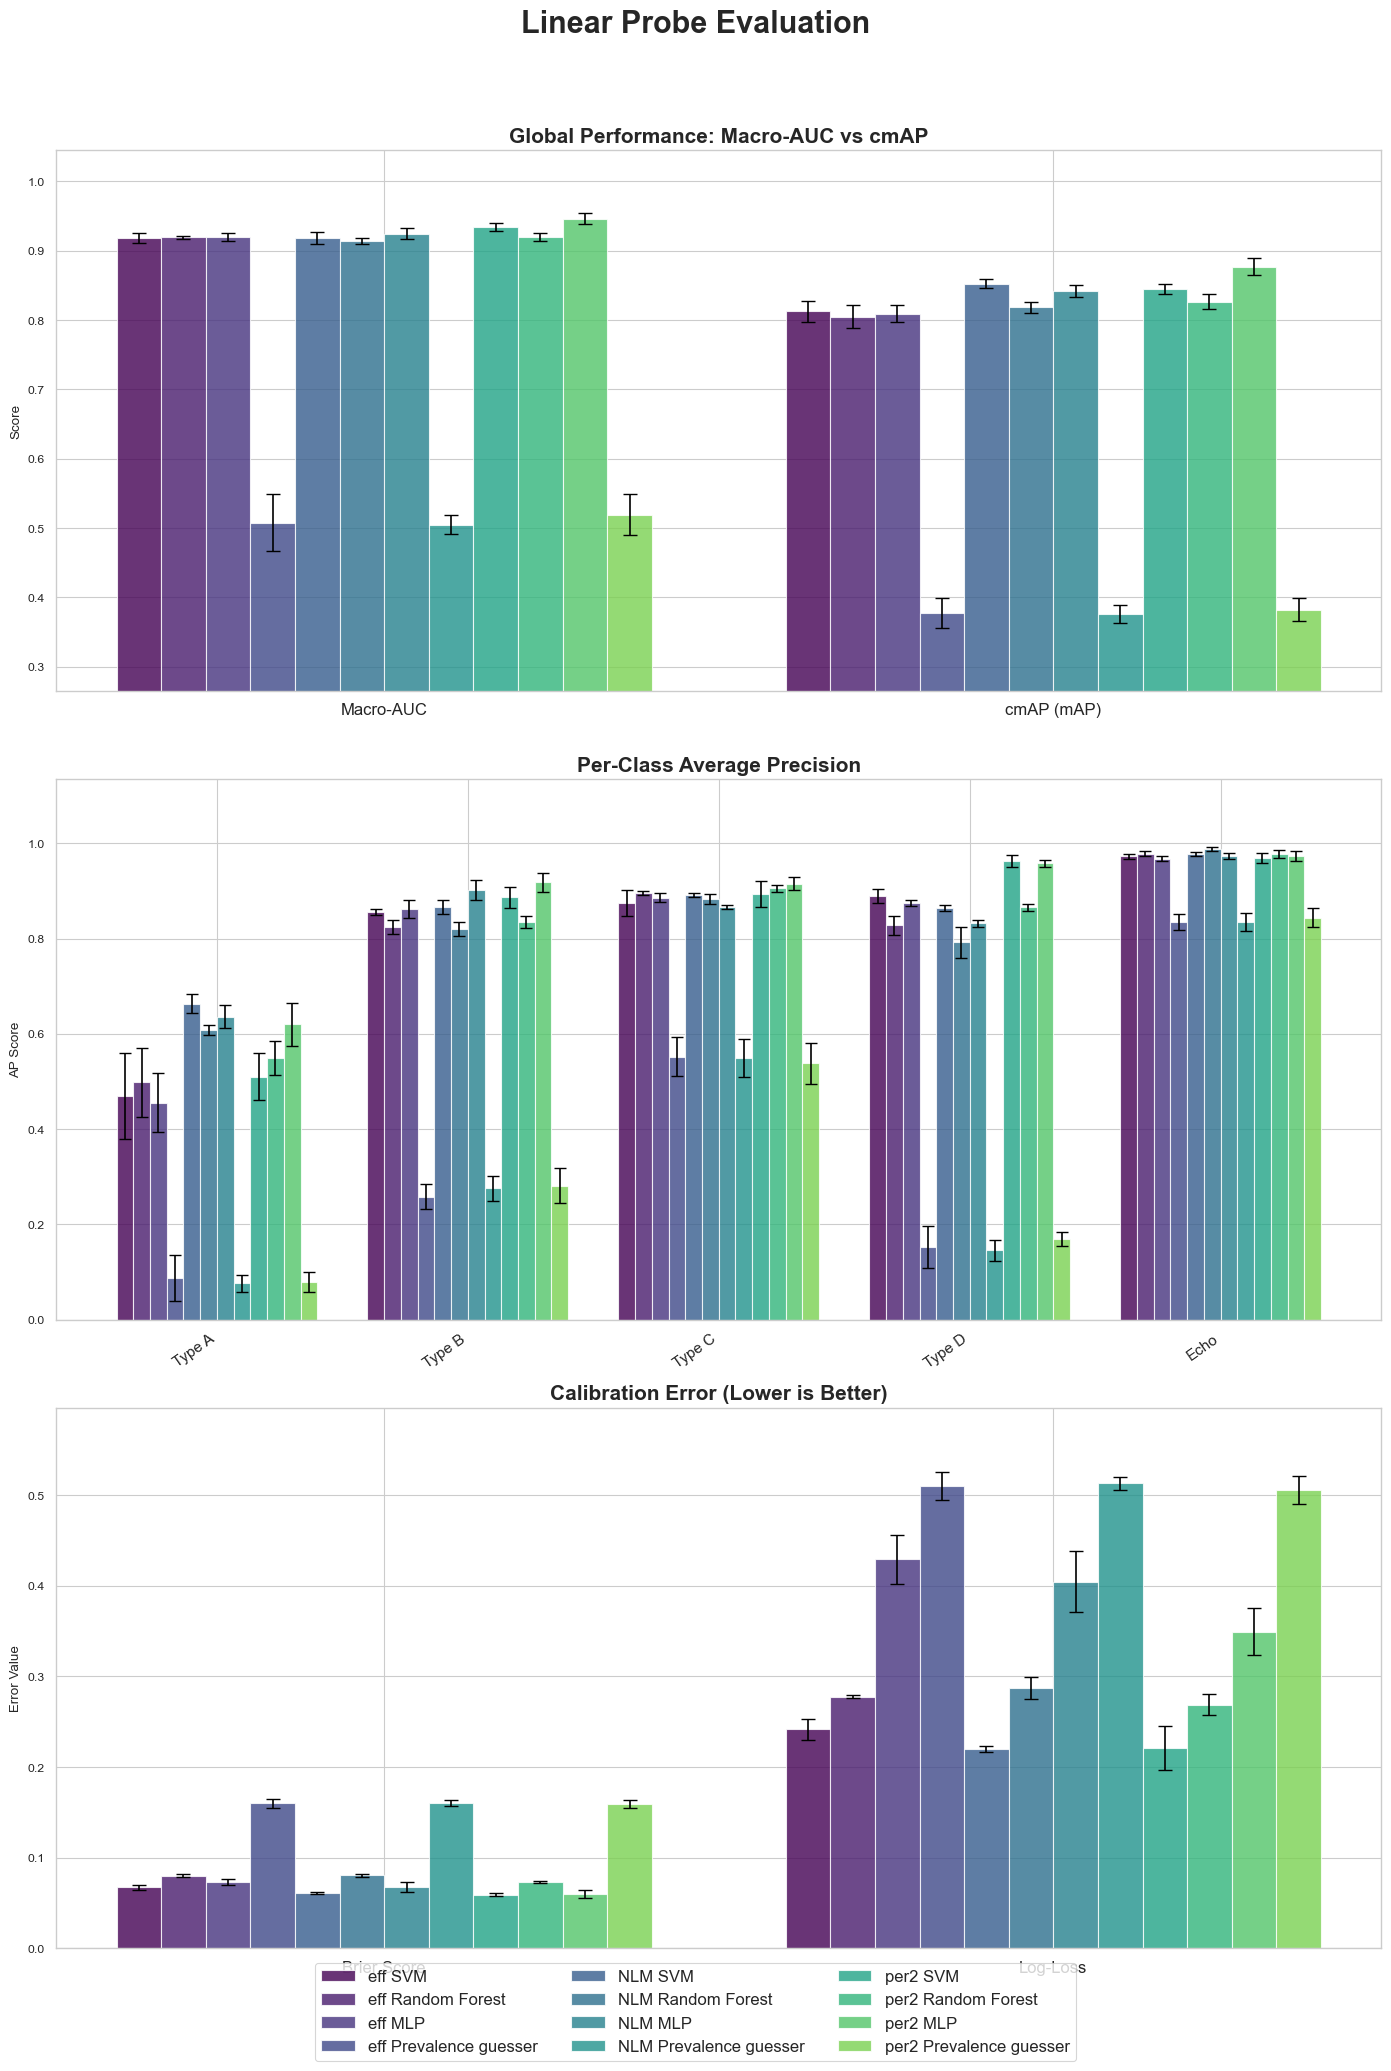

In [114]:
from evaluation.metrics import plot_comprehensive_results3

plot_comprehensive_results3(results, labels=label_names, title="Linear Probe Evaluation")

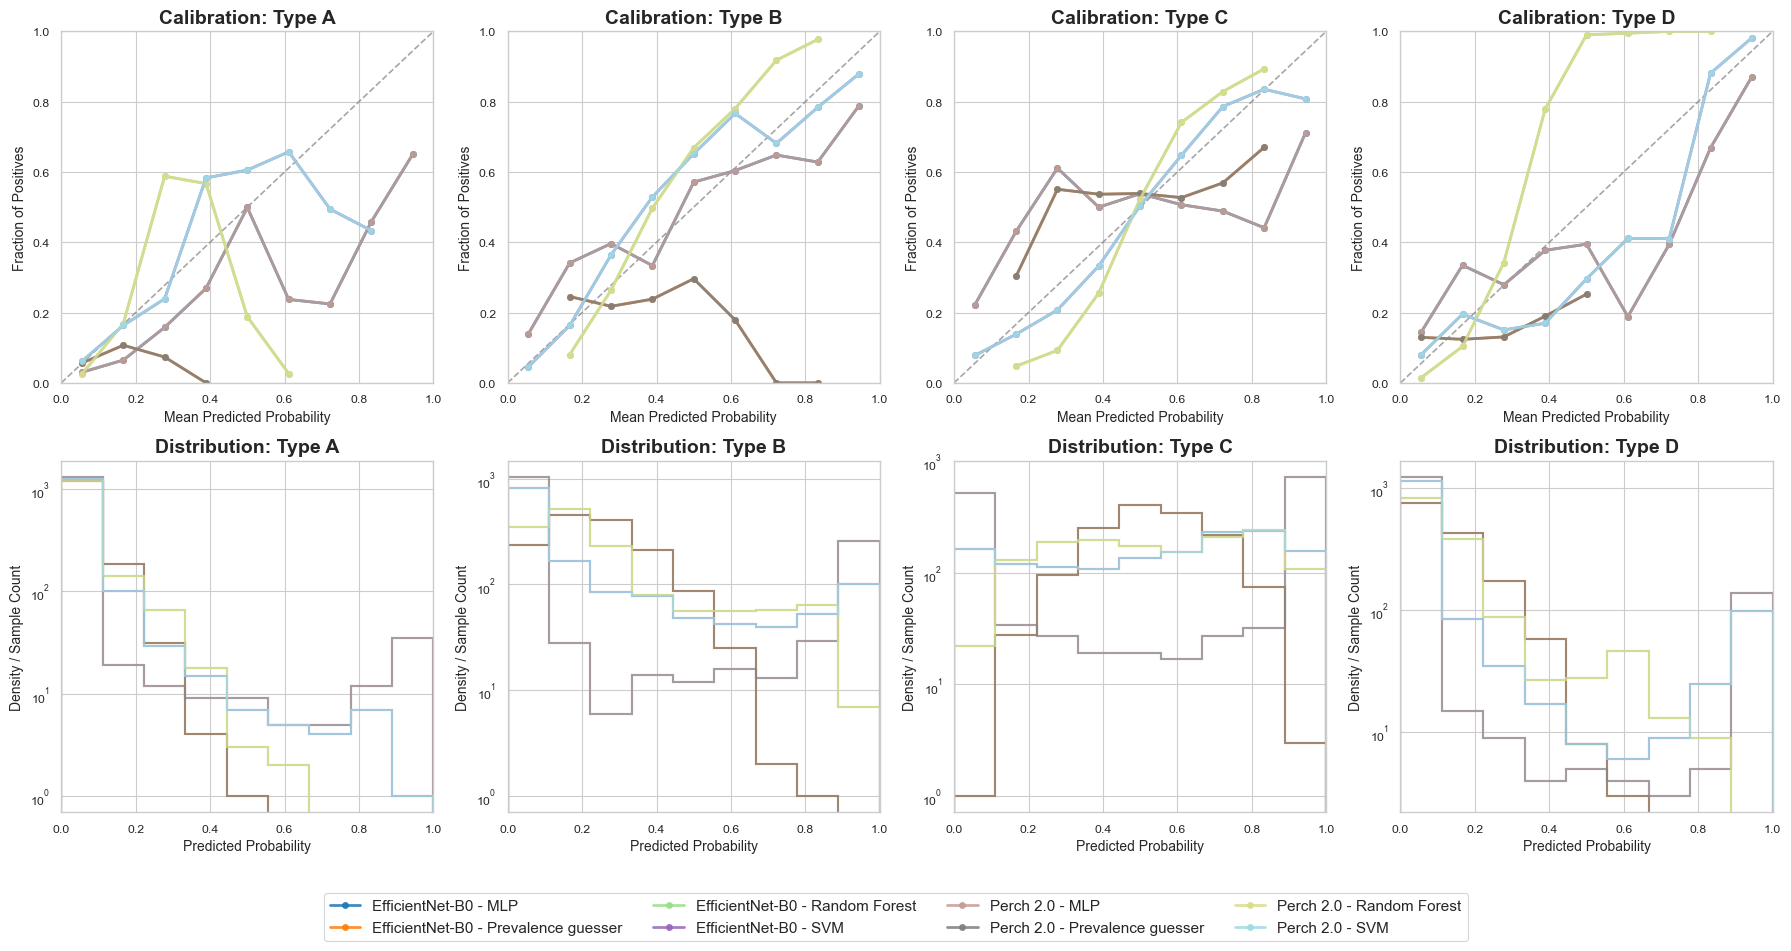

In [42]:
my_pipeline_results = {
    "EfficientNet-B0": all_results,                     # Your actual trial dictionary list
    "Perch 2.0": all_results    # Alternative encoder trial list
}

target_labels = ['Type A', 'Type B', 'Type C', 'Type D']

# 2. Render your visual evaluation assets
plot_comprehensive_calibration(
    encoder_results=my_pipeline_results, 
    label_names=target_labels, 
    n_bins=10, 
    strategy="uniform"
)

In [84]:
#testing with echo filtered
dir = Path(os.getcwd()).resolve().parent 
path = str(dir / "models" / "features")
with np.load(path + "\\perch2_no_echo2.npz") as data :
    X_per2_no_echo =pool_features( data['pooled_feats'], windows=False, window_pooled=True, method='mean',encoder="perch2")
    y = data['labels']
results_no_echo = linear_probe_tuned(X_per2_no_echo, y[:,:4], n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3

In [85]:
from tabulate import tabulate
label_names = ['Type A', 'Type B', 'Type C', 'Type D']
results_no_echo_compiled = compile_results(results_no_echo,label_names=label_names,encoder="")
df = pd.DataFrame(generate_metrics_table2(results_no_echo_compiled,label_names=label_names)[0])
print(tabulate(df, headers='keys', tablefmt='psql'))

+----+--------------------+---------------+-------------------+-----------------+---------------+
|    | Model              | Macro-AUC     | Macro-AP (cmAP)   | Brier Score ↓   | Log-Loss ↓    |
|----+--------------------+---------------+-------------------+-----------------+---------------|
|  0 | SVM                | 0.935 ± 0.006 | 0.829 ± 0.016     | 0.057 ± 0.001   | 0.204 ± 0.005 |
|  1 | Random Forest      | 0.923 ± 0.003 | 0.802 ± 0.014     | 0.077 ± 0.001   | 0.273 ± 0.013 |
|  2 | MLP                | 0.938 ± 0.005 | 0.848 ± 0.010     | 0.061 ± 0.005   | 0.371 ± 0.025 |
|  3 | Prevalence guesser | 0.508 ± 0.024 | 0.259 ± 0.014     | 0.162 ± 0.002   | 0.515 ± 0.009 |
+----+--------------------+---------------+-------------------+-----------------+---------------+


In [86]:
df2 = pd.DataFrame(generate_metrics_table2(results_no_echo_compiled,label_names=label_names)[1])
print(tabulate(df2, headers='keys', tablefmt='psql'))

+----+--------------------+---------------+---------------+---------------+---------------+
|    | Model              | Type A AP     | Type B AP     | Type C AP     | Type D AP     |
|----+--------------------+---------------+---------------+---------------+---------------|
|  0 | SVM                | 0.529 ± 0.066 | 0.902 ± 0.011 | 0.907 ± 0.013 | 0.978 ± 0.008 |
|  1 | Random Forest      | 0.545 ± 0.054 | 0.848 ± 0.006 | 0.913 ± 0.007 | 0.903 ± 0.009 |
|  2 | MLP                | 0.587 ± 0.041 | 0.929 ± 0.009 | 0.915 ± 0.005 | 0.961 ± 0.006 |
|  3 | Prevalence guesser | 0.072 ± 0.029 | 0.259 ± 0.021 | 0.545 ± 0.033 | 0.161 ± 0.015 |
+----+--------------------+---------------+---------------+---------------+---------------+


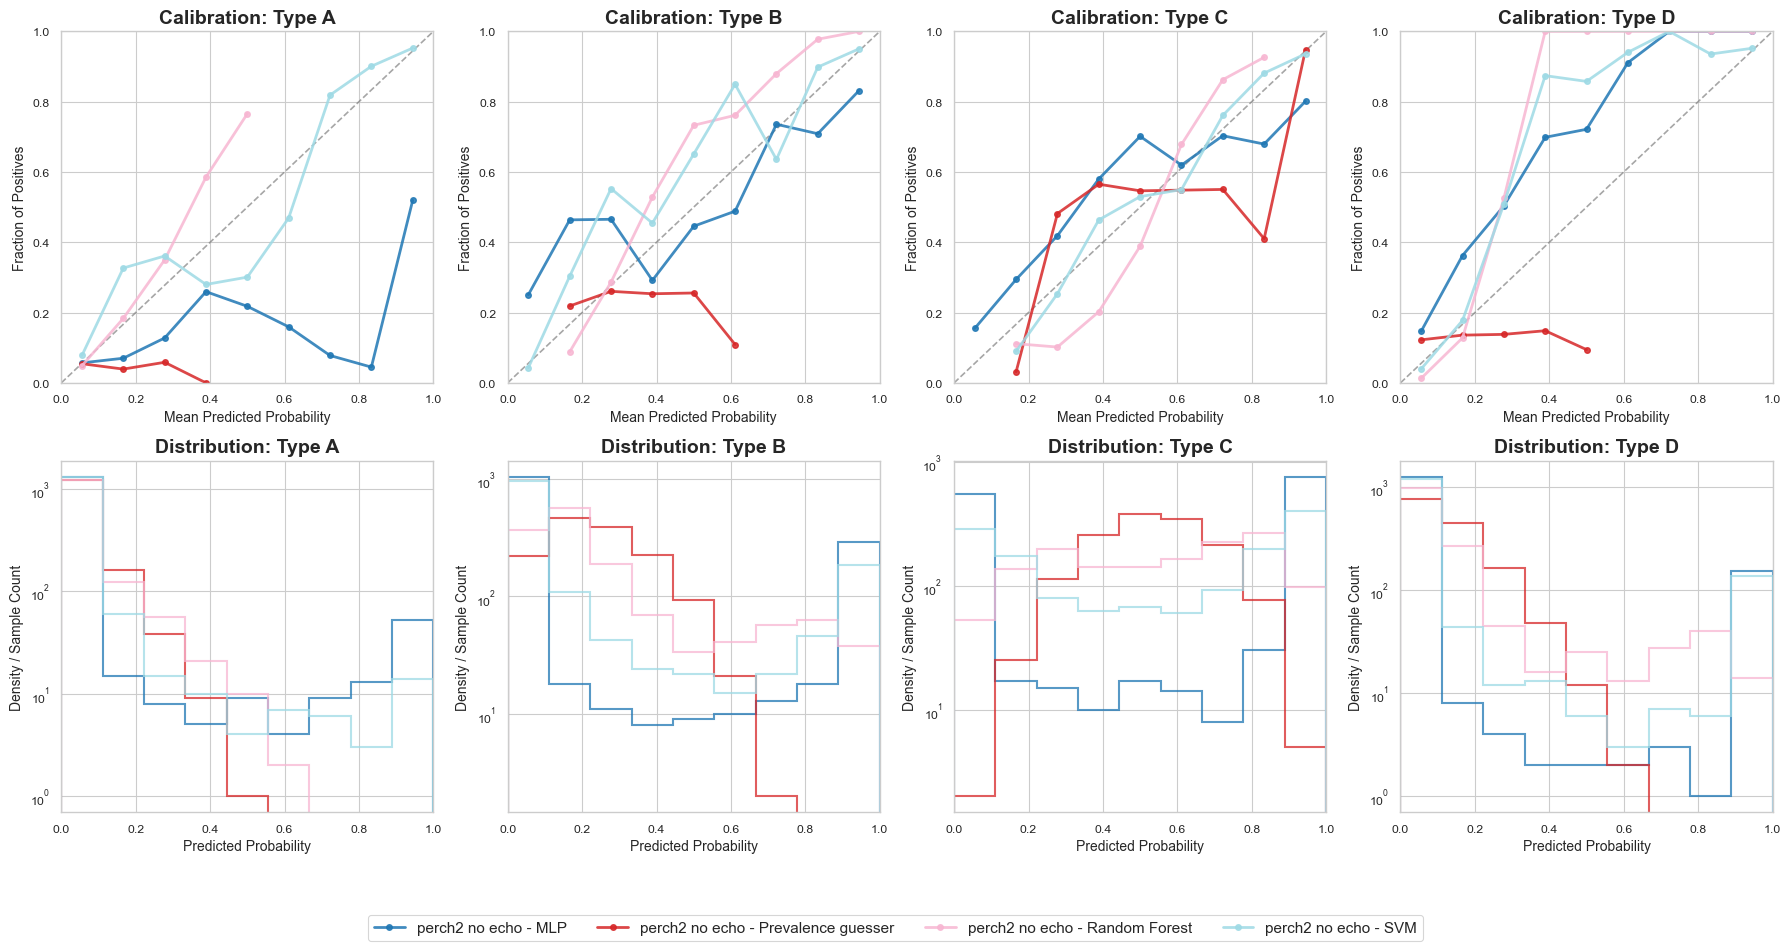

In [88]:
pipeline = {
    'perch2 no echo' : results_no_echo,
}
plot_comprehensive_calibration(
    encoder_results=pipeline, 
    label_names=label_names, 
    n_bins=10, 
    strategy="uniform"
)

In [93]:
#Testing on balanced test set
from testing.linear_probe_tests import balanced_test
balanced_results = balanced_test(X_eff0_pooled, y, folds = 5, random_state=42)

Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: SVM, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: Random Forest, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: MLP, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: 

In [94]:
balanced_results2 = balanced_test(X_per2_pooled, y, folds = 5, random_state=42)

Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: SVM, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: Random Forest, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: MLP, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: 

In [96]:
balanced_results3 = balanced_test(X_NLM_pooled, y, folds = 5, random_state=42)

Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: SVM, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: Random Forest, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: MLP, Train samples: 253, Test samples: 31
Original stratified test counts per class: [ 4. 13. 30.  7. 47.]
Target uniform capacity per class: 13
Final balanced test counts per class: [ 4. 13. 13.  7. 24.]
Final split size: Train=253, Test=31
Trial 1, Model: 

In [102]:
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']

eff0_results2 = compile_results(balanced_results,label_names=label_names,encoder="eff")
NLM_results2 = compile_results(balanced_results3,label_names=label_names,encoder="NLM")
per2_results2 = compile_results(balanced_results2,label_names=label_names,encoder="per2")

results5 = eff0_results2 | NLM_results2 | per2_results2
#print(pd.DataFrame(results))
df = pd.DataFrame(generate_metrics_table2(results5,label_names=label_names)[1])
print(tabulate(df, headers='keys', tablefmt='psql'))

+----+---------------------+---------------+---------------+---------------+---------------+---------------+
|    | Model               | Type A AP     | Type B AP     | Type C AP     | Type D AP     | Echo AP       |
|----+---------------------+---------------+---------------+---------------+---------------+---------------|
|  0 | eff SVM             | 0.662 ± 0.195 | 0.922 ± 0.044 | 0.816 ± 0.068 | 0.959 ± 0.042 | 0.996 ± 0.002 |
|  1 | eff Random Forest   | 0.762 ± 0.181 | 0.873 ± 0.058 | 0.842 ± 0.071 | 0.930 ± 0.076 | 0.999 ± 0.002 |
|  2 | eff MLP             | 0.660 ± 0.205 | 0.924 ± 0.054 | 0.813 ± 0.076 | 0.948 ± 0.045 | 0.991 ± 0.013 |
|  3 | eff Random Guesser  | 0.175 ± 0.049 | 0.469 ± 0.082 | 0.516 ± 0.121 | 0.334 ± 0.146 | 0.770 ± 0.092 |
|  4 | NLM SVM             | 0.786 ± 0.265 | 0.920 ± 0.051 | 0.885 ± 0.022 | 0.965 ± 0.026 | 0.993 ± 0.007 |
|  5 | NLM Random Forest   | 0.749 ± 0.118 | 0.876 ± 0.070 | 0.846 ± 0.078 | 0.913 ± 0.067 | 0.994 ± 0.005 |
|  6 | NLM MLP     

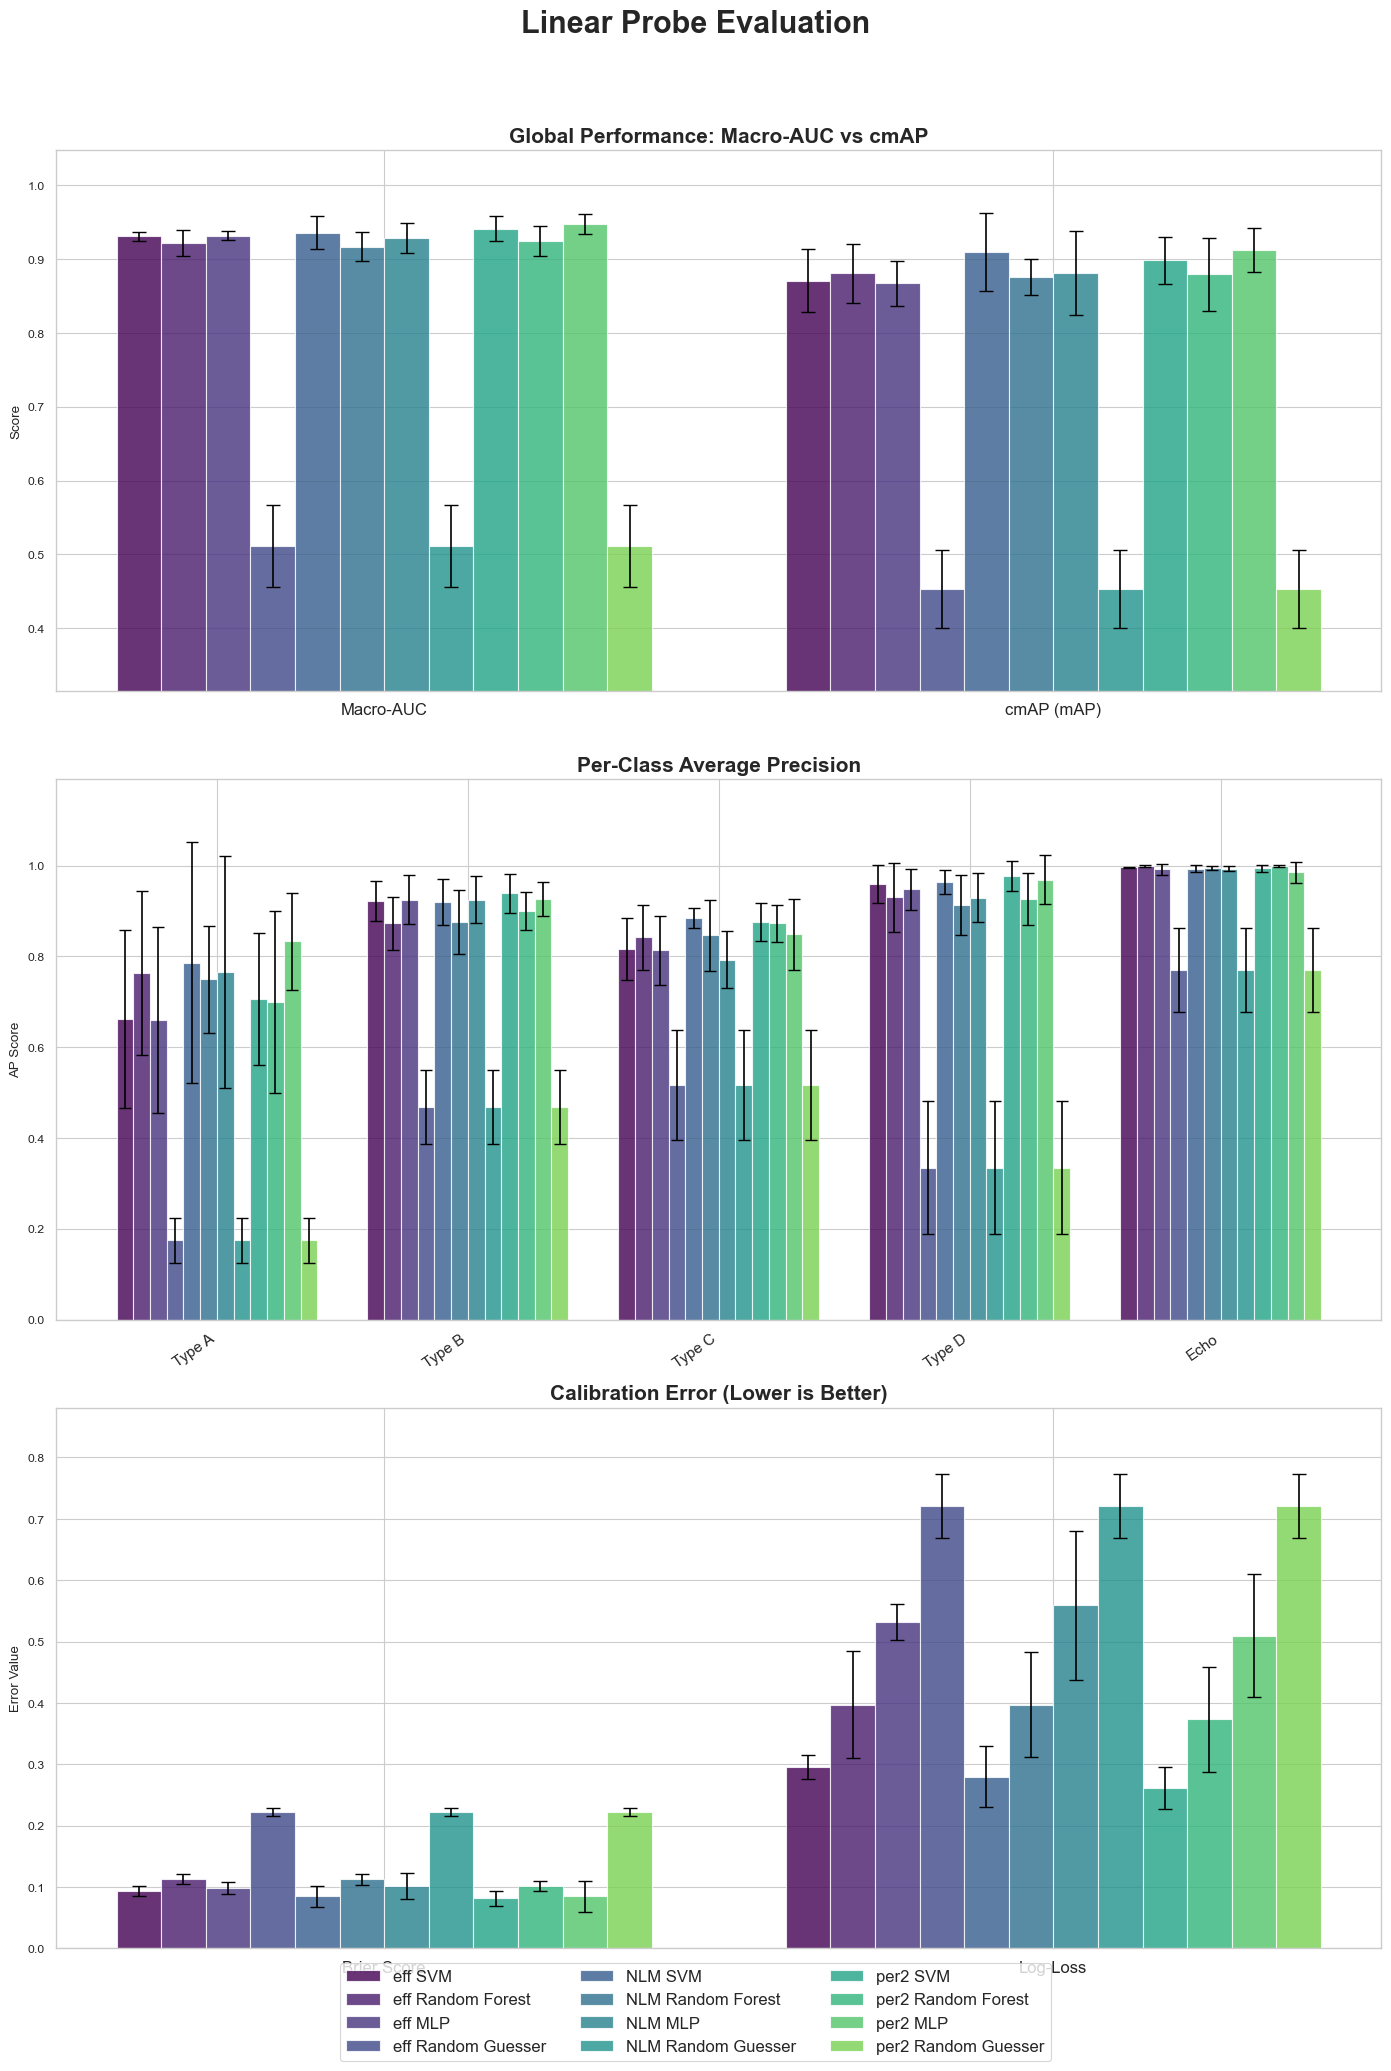

In [101]:
from evaluation.metrics import plot_comprehensive_results3
plot_comprehensive_results3(results5, labels=label_names, title="Linear Probe Evaluation")

In [ ]:
balanced_result = compile_results(balanced_results,label_names=label_names,encoder="eff_balanced")
print(generate_metrics_table2(balanced_result,label_names=label_names)[1])

In [ ]:
per2_balancing_results = balancing_mlp(X_per2_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_ClassWeights
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_FocalLoss
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_Oversampled
    Evaluating fold 1/5
Final counts: [189 189 202 189 364]
    Evaluating fold 2/5
Final counts: [189 189 230 189 390]
    Evaluating fold 3/5
Final counts: [189 189 216 189 409]
    Evaluating fold 4/5
Final counts: [189 189 238 189 378]
    Evaluating fold 5/5
Final counts: [188 188 195 188 372]
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
  

In [116]:
per2_balanced_mlp_results_ = compile_results(per2_balancing_results,label_names=label_names,encoder="eff_balanced")
print(generate_metrics_table2(per2_balanced_mlp_results_,label_names=label_names)[0])

                           Model      Macro-AUC Macro-AP (cmAP)  \
0   eff_balanced MLP_Oversampled  0.938 ± 0.006   0.862 ± 0.009   
1  eff_balanced MLP_ClassWeights  0.944 ± 0.004   0.873 ± 0.010   
2      eff_balanced MLP_Baseline  0.948 ± 0.003   0.880 ± 0.008   
3     eff_balanced MLP_FocalLoss  0.943 ± 0.007   0.876 ± 0.014   

   Brier Score ↓     Log-Loss ↓  
0  0.066 ± 0.004  0.471 ± 0.047  
1  0.063 ± 0.004  0.338 ± 0.022  
2  0.060 ± 0.003  0.352 ± 0.014  
3  0.058 ± 0.003  0.248 ± 0.016  


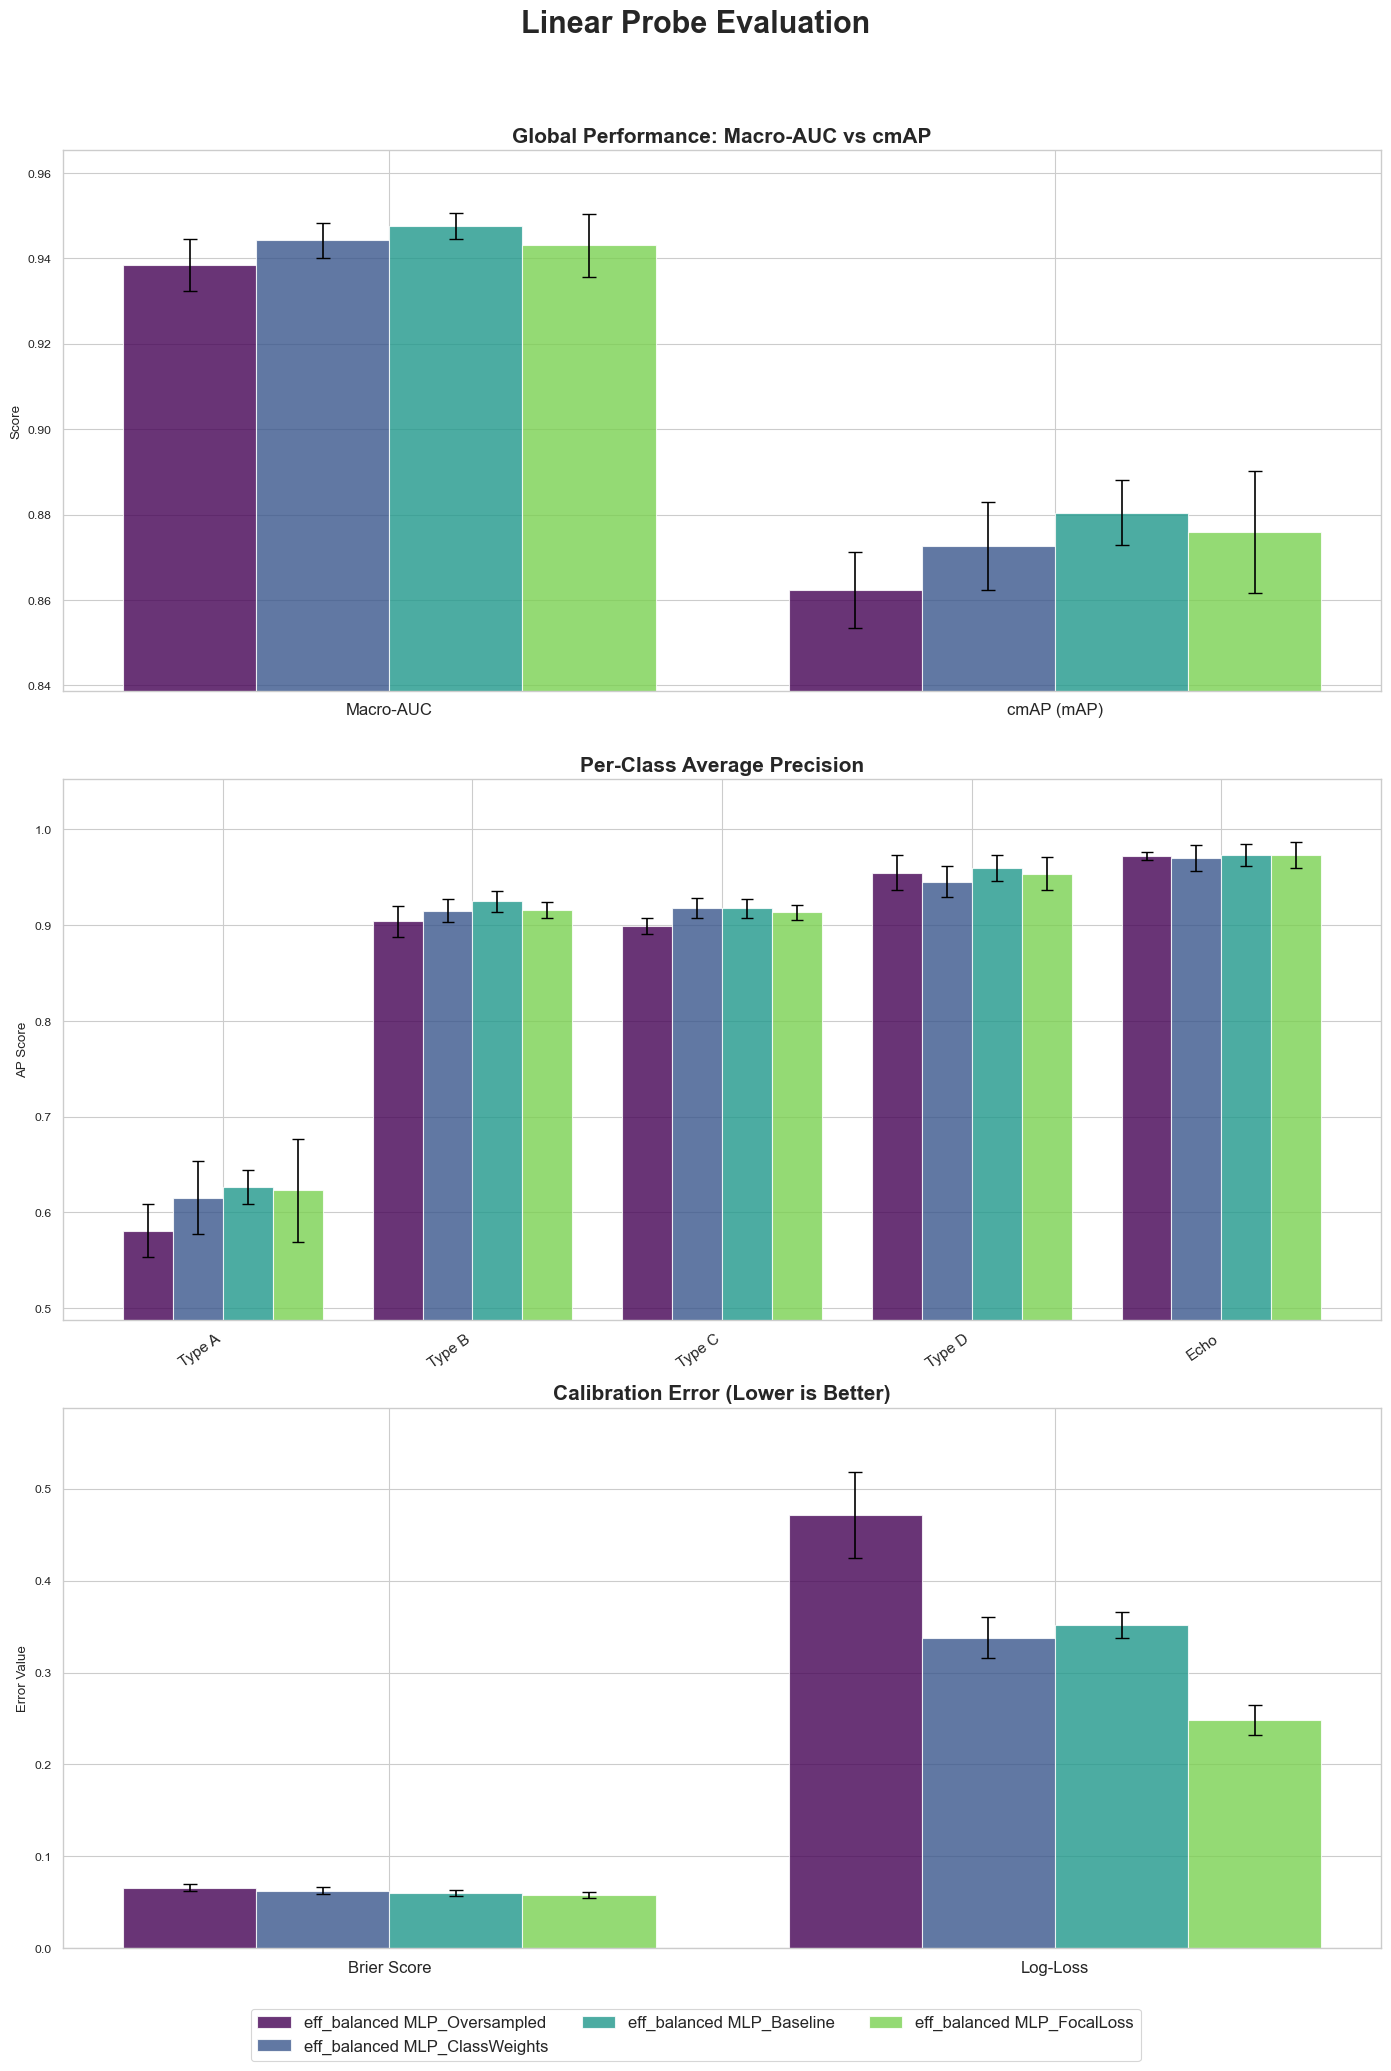

In [117]:
plot_comprehensive_results3(per2_balanced_mlp_results_, labels=label_names, title="Linear Probe Evaluation")

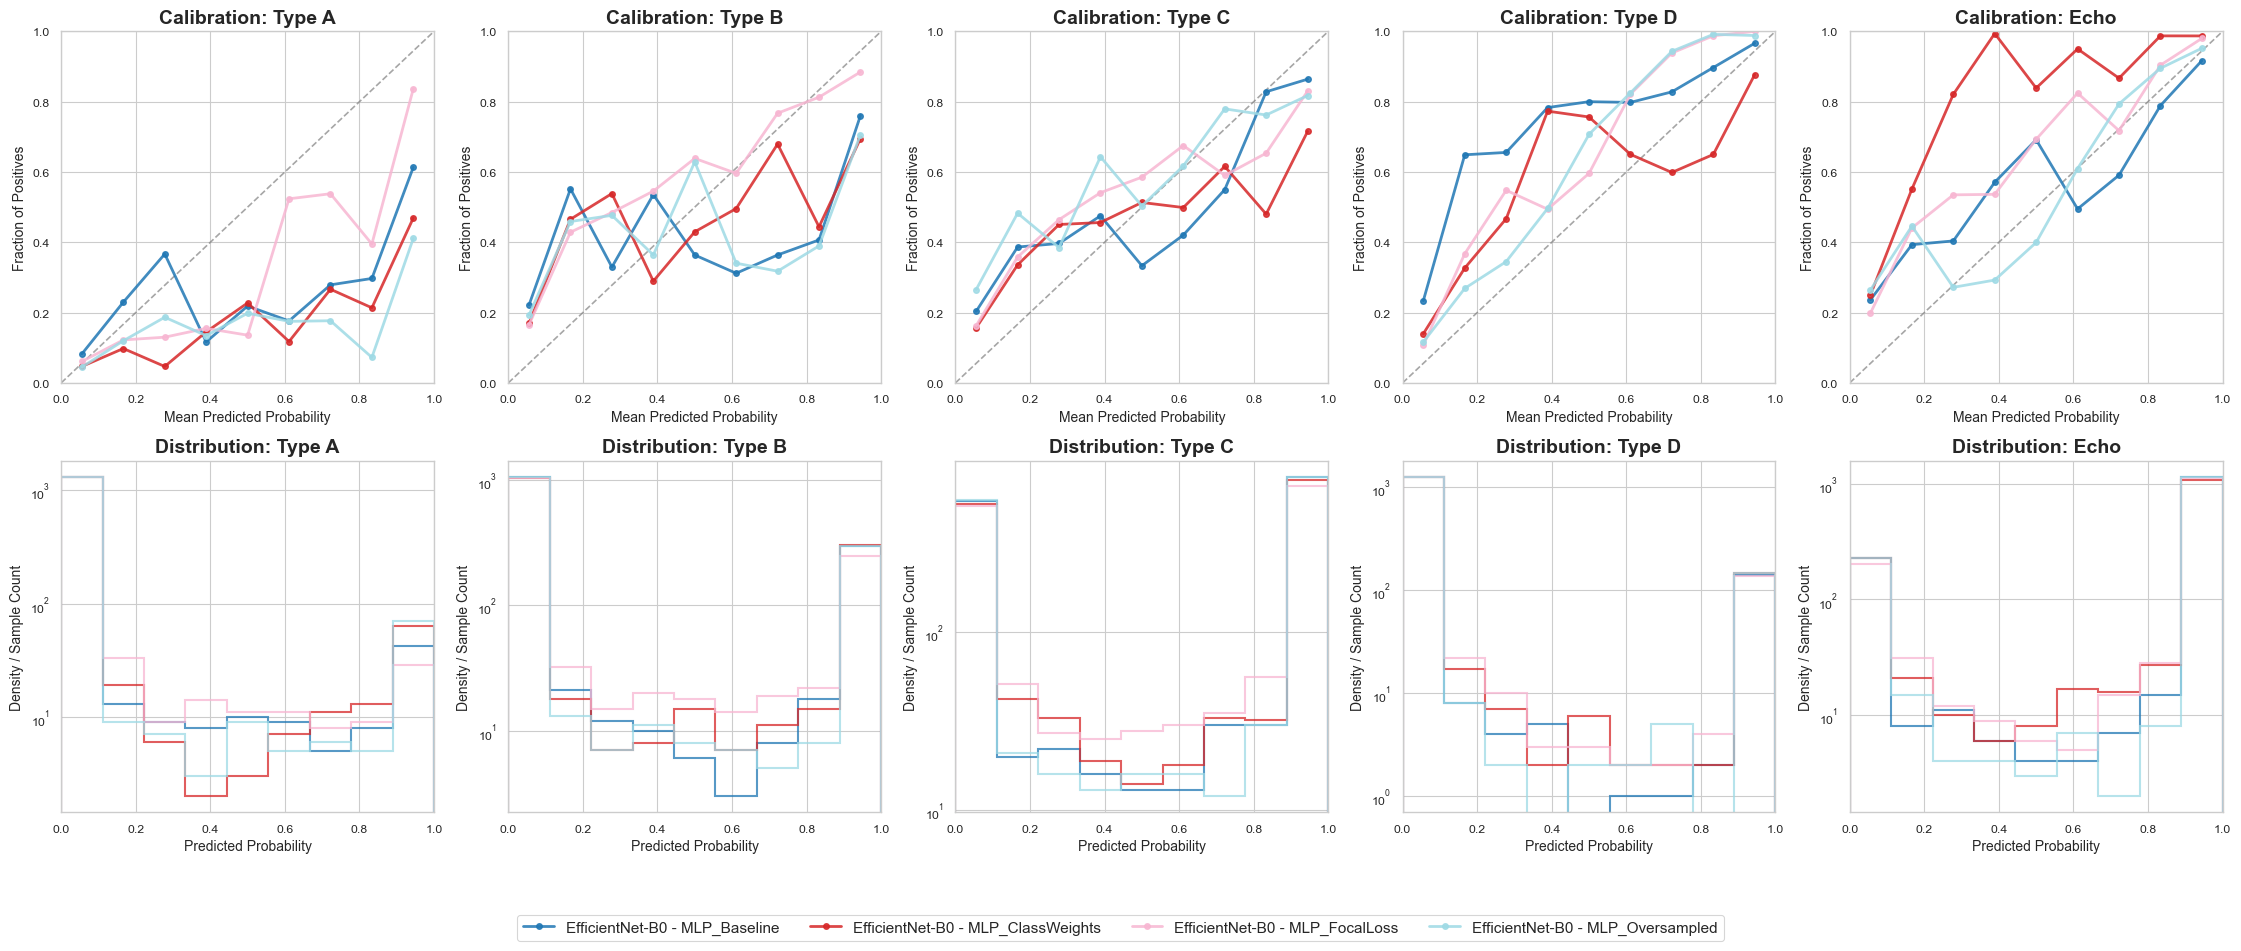

In [118]:
my_pipeline_results = {
    "EfficientNet-B0": per2_balancing_results                 # Your actual trial dictionary list
}

target_labels = ['Type A', 'Type B', 'Type C', 'Type D','Echo']

# 2. Render your visual evaluation assets
plot_comprehensive_calibration(
    encoder_results=my_pipeline_results, 
    label_names=target_labels, 
    n_bins=10, 
    strategy="uniform"
)

In [12]:
#Testing feature extraction (without echo)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
encoder = "perch2"
encoder_model = extract_encoder(encoder)
dir = Path(os.getcwd()).resolve().parent / "data"
batdata = PipistrelleDataset(data_input=str(dir / "bat_metadata.csv"),
                             root_dir=str(dir / "xenocanto-dataset"),
                             encoder = encoder,
                             filter_echo = True)

features,labels = build_feature_bank(batdata, encoder_model, encoder, device=device)

Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting perch2: 100%|██████████| 284/284 [27:55<00:00,  5.90s/it]


In [21]:
print(len(features))
pooled_feats = pool_features(features,windows= True ,window_pooled = False, method ='mean',encoder = 'perch2')
print(pooled_feats.shape)
npz_file_path = 'perch2_no_echo2.npz'
np.savez(str(npz_file_path), pooled_feats=pooled_feats, labels=labels)

284
(284, 16, 4, 1536)


In [22]:
dir = Path(os.getcwd()).resolve().parent 
path = str(dir / "models" / "features")
with np.load(path + "\\perch2_no_echo2.npz") as data :
    feat22 = data['pooled_feats']
    label22 = data['labels']


In [23]:
print(label22.shape,feat22.shape)

(284, 5) (284, 16, 4, 1536)


In [ ]:


#Write features
with open('features_perch_unpooled.txt','w+') as f :
    for items in features :
        f.write('%s\n' %items)
    print("file written")
f.close()
#Read features
with open('bat_features_mil.pkl','rb') as f :
    loaded_features = pickle.load(f) 


In [4]:
#implementing abMIL
current_dir = Path(os.getcwd()).resolve()
target_dir = current_dir.parent / "models" / "features"

with open(target_dir / "bat_features_mil.pkl", 'rb') as f:
    loaded_features = pickle.load(f)
y_new = np.load(target_dir / "Y_labels2_not_normalized.npy")
X_bags = pool_features(loaded_features, windows=False, window_pooled=False, method='mean', encoder='perch2')

In [6]:
from models.abmil_model import tune_abmil_single_split
abmil_results = tune_abmil_single_split(X_bags, y_new, n_trials=10, random_state=42)

Data Allocated -> Train: 186 bags | Val: 50 bags | Test: 48 bags
Type A counts  -> Train: 10 | Val: 3 | Test: 3

Evaluating Trial 1/4: {'hidden_dim': 128, 'attention_dim': 64, 'learning_rate': 0.001, 'weight_decay': 0.0001}
Early stopping at epoch 15
-> Validation Macro AP: 0.9165
Evaluating Trial 2/4: {'hidden_dim': 128, 'attention_dim': 128, 'learning_rate': 0.0005, 'weight_decay': 0.001}
Early stopping at epoch 13
-> Validation Macro AP: 0.9429
Evaluating Trial 3/4: {'hidden_dim': 256, 'attention_dim': 128, 'learning_rate': 0.001, 'weight_decay': 1e-05}
Early stopping at epoch 13
-> Validation Macro AP: 0.9618
Evaluating Trial 4/4: {'hidden_dim': 64, 'attention_dim': 32, 'learning_rate': 0.0005, 'weight_decay': 0.01}
Early stopping at epoch 17
-> Validation Macro AP: 0.9339

OPTIMIZATION COMPLETE
Best Hyperparameters: {'hidden_dim': 256, 'attention_dim': 128, 'learning_rate': 0.001, 'weight_decay': 1e-05}
Final Vaulted Test Macro AP: 0.9754


In [61]:
from models.abmil_model import abmil_classifier_tuned
abmil_results2 = abmil_classifier_tuned(X_bags, y_new, n_split_out=5,n_split_in=3, num_trials=1,random_state=42,n_iter_search = 3)

Starting Trial 1/1 with random_state=42...
  Tuning and evaluating model: ABMIL
    Evaluating fold 1/5
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Early stopping at epoch 16
[CV 1/3] END attention_dim=128, dropout=0.1, hidden_dim=256, learning_rate=0.0017524101118128151, weight_decay=0.0002481040974867811;, score=nan total time=  13.8s
Early stopping at epoch 20
[CV 2/3] END attention_dim=128, dropout=0.1, hidden_dim=256, learning_rate=0.0017524101118128151, weight_decay=0.0002481040974867811;, score=nan total time=  17.2s
Early stopping at epoch 22
[CV 3/3] END attention_dim=128, dropout=0.1, hidden_dim=256, learning_rate=0.0017524101118128151, weight_decay=0.0002481040974867811;, score=nan total time=  19.0s
Early stopping at epoch 36
[CV 1/3] END attention_dim=128, dropout=0.3, hidden_dim=256, learning_rate=0.00014786125334132768, weight_decay=6.870614282613295e-05;, score=nan total time=  30.8s
Early stopping at epoch 19
[CV 2/3] END attention_dim=128, dropout=0.3, 

In [62]:
from tabulate import tabulate
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']
abmil2_results_compiled = compile_results(abmil_results2,label_names=label_names,encoder="")
df = pd.DataFrame(generate_metrics_table2(abmil2_results_compiled,label_names=label_names)[0])
print(tabulate(df, headers='keys', tablefmt='psql'))


+----+---------+---------------+-------------------+-----------------+---------------+
|    | Model   | Macro-AUC     | Macro-AP (cmAP)   | Brier Score ↓   | Log-Loss ↓    |
|----+---------+---------------+-------------------+-----------------+---------------|
|  0 | ABMIL   | 0.945 ± 0.000 | 0.883 ± 0.000     | 0.056 ± 0.000   | 0.289 ± 0.000 |
+----+---------+---------------+-------------------+-----------------+---------------+


In [63]:
df2 = pd.DataFrame((generate_metrics_table2(abmil2_results_compiled,label_names=label_names)[1]))
print(tabulate(df2, headers='keys', tablefmt='psql'))

+----+---------+---------------+---------------+---------------+---------------+---------------+
|    | Model   | Type A AP     | Type B AP     | Type C AP     | Type D AP     | Echo AP       |
|----+---------+---------------+---------------+---------------+---------------+---------------|
|  0 | ABMIL   | 0.622 ± 0.000 | 0.916 ± 0.000 | 0.921 ± 0.000 | 0.968 ± 0.000 | 0.984 ± 0.000 |
+----+---------+---------------+---------------+---------------+---------------+---------------+


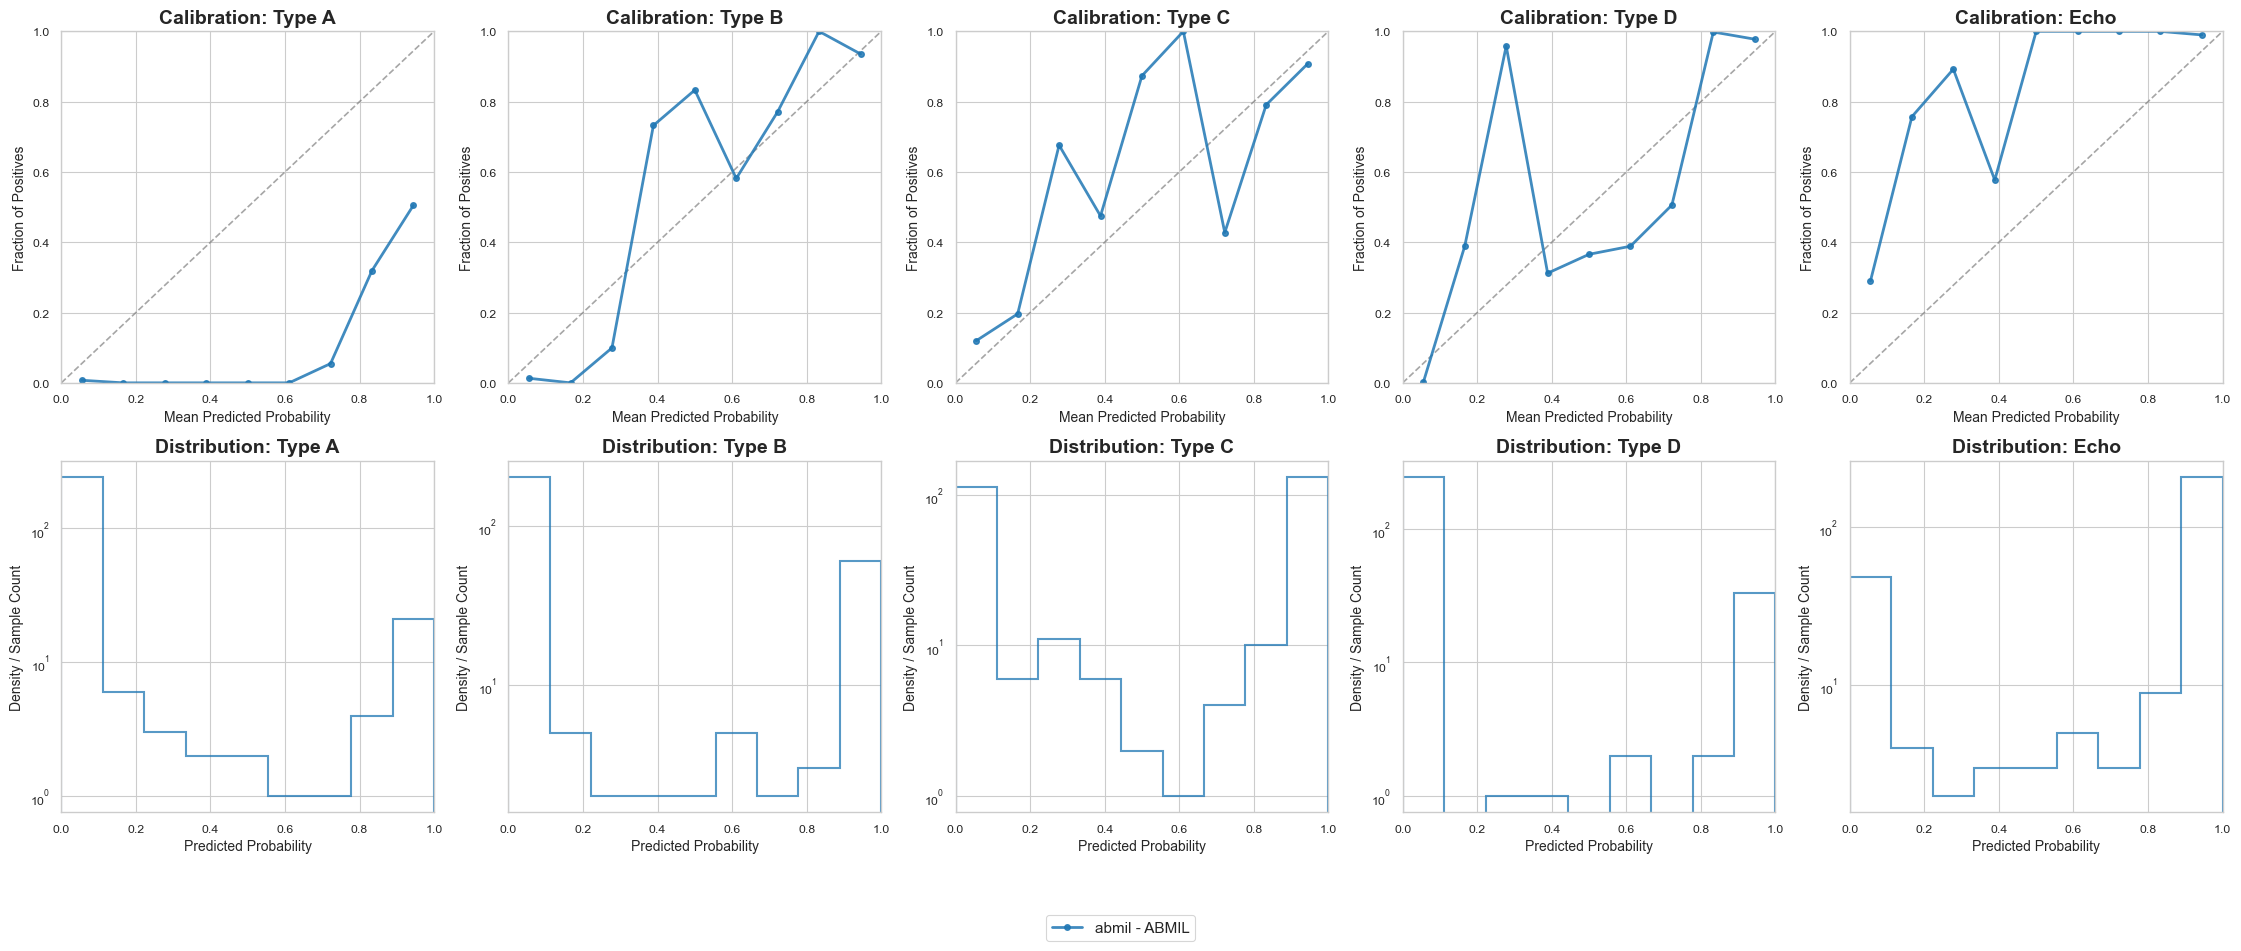

In [64]:
pipeline = {
    'abmil' : abmil_results2,
}
plot_comprehensive_calibration(
    encoder_results=pipeline, 
    label_names=label_names, 
    n_bins=10, 
    strategy="uniform"
)

In [54]:
from models.hierarchal_classifier import HierarchicalABMIL
stage2_abmil = HierarchicalABMIL(device = 'cuda',verbose = True).fit(X_bags, y_new, n_splits_outer=2, n_splits_inner=2, 
            n_iter_search=2)

TRAINING UNIFIED MULTI-TASK HIERARCHY (6 Labels)

Fold 1/2
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Early stopping at epoch 12
[CV 1/2] END attention_dim=128, dropout=0.1, hidden_dim=256, lambda_penalty=2.5, learning_rate=0.0021118915966823948, weight_decay=0.00024400607090817574;, score=nan total time=   6.9s
Early stopping at epoch 21
[CV 2/2] END attention_dim=128, dropout=0.1, hidden_dim=256, lambda_penalty=2.5, learning_rate=0.0021118915966823948, weight_decay=0.00024400607090817574;, score=nan total time=  10.9s
Early stopping at epoch 19
[CV 1/2] END attention_dim=64, dropout=0.5, hidden_dim=256, lambda_penalty=2.5, learning_rate=0.0006029066747914362, weight_decay=2.1618942406574445e-05;, score=nan total time=  10.6s
Early stopping at epoch 31
[CV 2/2] END attention_dim=64, dropout=0.5, hidden_dim=256, lambda_penalty=2.5, learning_rate=0.0006029066747914362, weight_decay=2.1618942406574445e-05;, score=nan total time=  15.8s
Early stopping at epoch 21
  Best pa

In [55]:
from tabulate import tabulate
stage2_results_adapted = {
    'trial' : 1,
    'model' : 'abMIL_2',
    'oof_y_true': stage2_abmil.mt_results['oof_y_true'],
    'oof_y_pred_proba': stage2_abmil.mt_results['oof_y_pred']
}

label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']
abmil_stage2_results_compiled = compile_results([stage2_results_adapted],label_names=label_names,encoder="")
df = pd.DataFrame(generate_metrics_table2(abmil_stage2_results_compiled,label_names=label_names)[0])
print(tabulate(df, headers='keys', tablefmt='psql'))


+----+---------+---------------+-------------------+-----------------+---------------+
|    | Model   | Macro-AUC     | Macro-AP (cmAP)   | Brier Score ↓   | Log-Loss ↓    |
|----+---------+---------------+-------------------+-----------------+---------------|
|  0 | abMIL_2 | 0.814 ± 0.000 | 0.745 ± 0.000     | 0.197 ± 0.000   | 0.586 ± 0.000 |
+----+---------+---------------+-------------------+-----------------+---------------+


In [56]:
df2 = pd.DataFrame(generate_metrics_table2(abmil_stage2_results_compiled,label_names=label_names)[1])
print(tabulate(df2, headers='keys', tablefmt='psql'))

+----+---------+---------------+---------------+---------------+---------------+---------------+
|    | Model   | Type A AP     | Type B AP     | Type C AP     | Type D AP     | Echo AP       |
|----+---------+---------------+---------------+---------------+---------------+---------------|
|  0 | abMIL_2 | 0.343 ± 0.000 | 0.917 ± 0.000 | 0.900 ± 0.000 | 0.585 ± 0.000 | 0.980 ± 0.000 |
+----+---------+---------------+---------------+---------------+---------------+---------------+


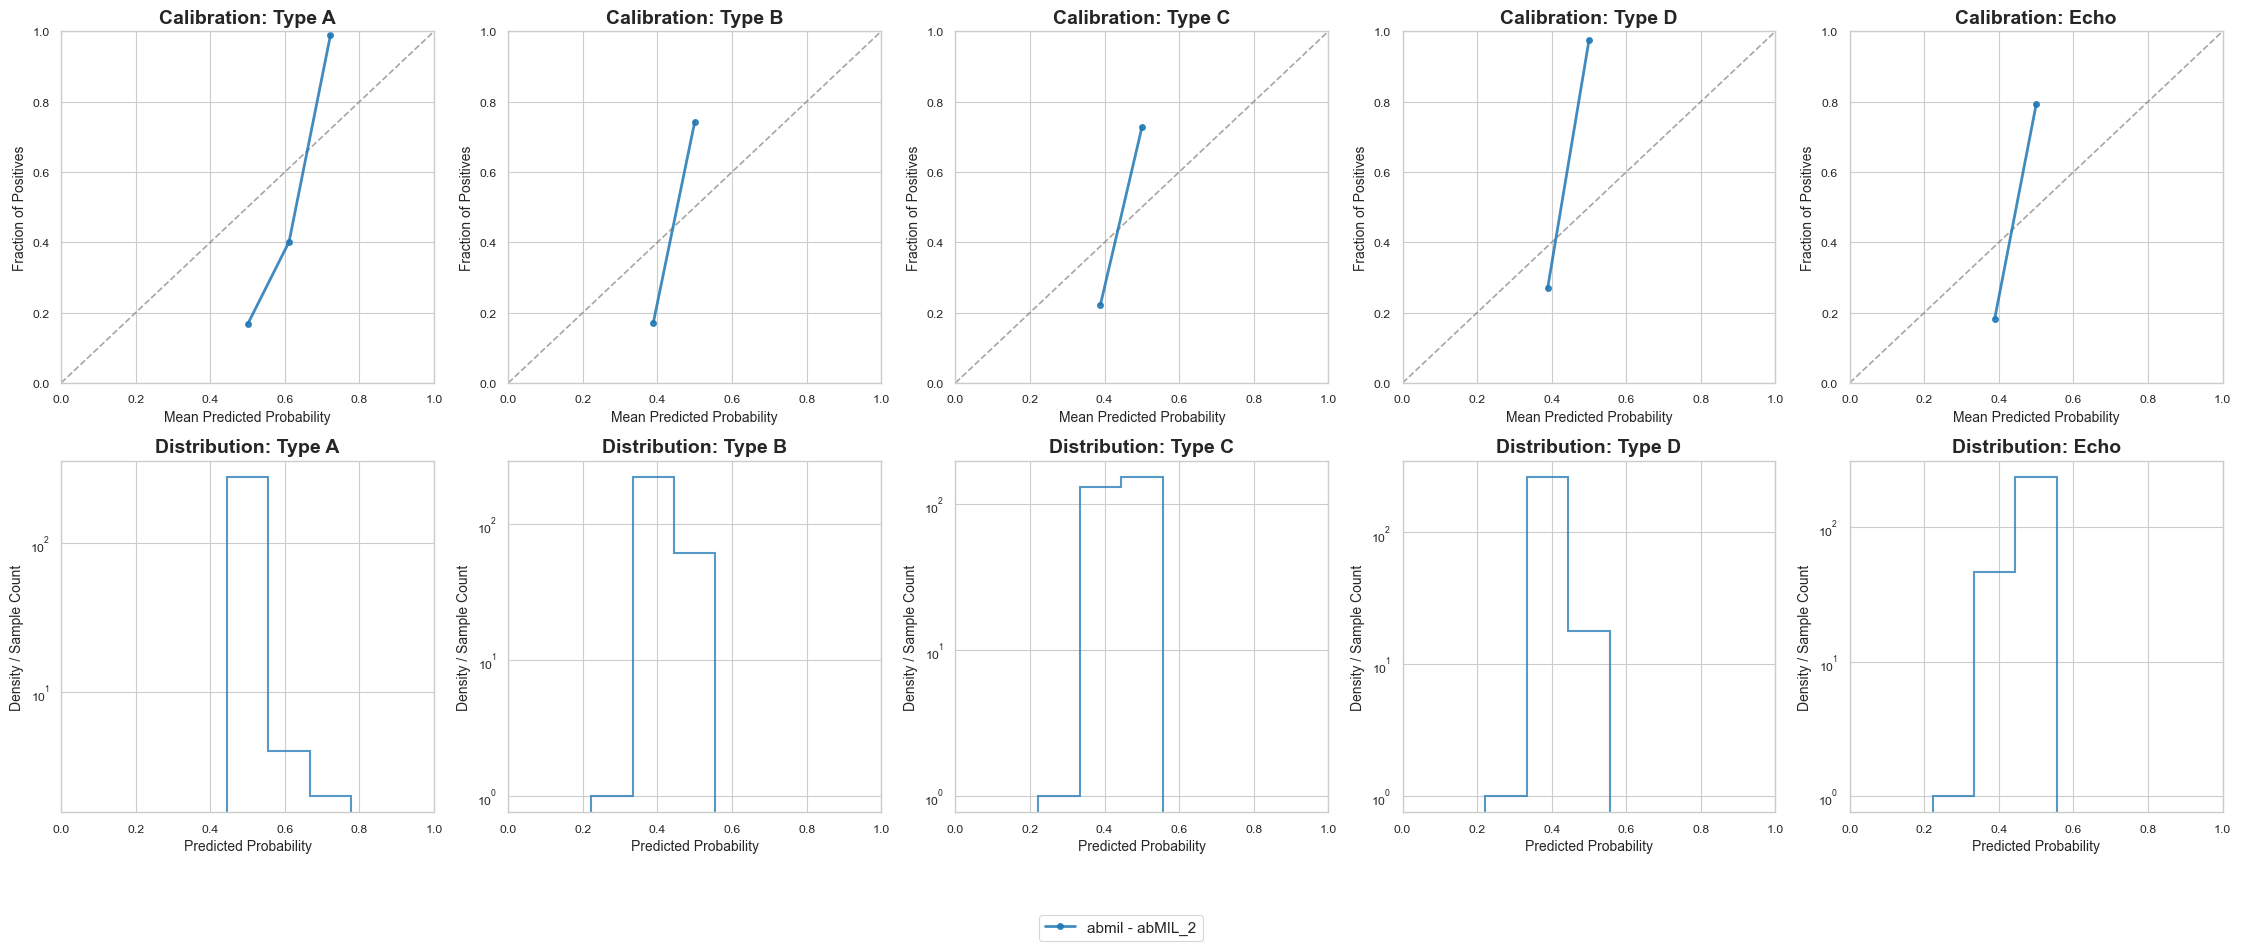

In [57]:
pipeline = {
    'abmil' : [stage2_results_adapted],
}
plot_comprehensive_calibration(
    encoder_results=pipeline, 
    label_names=label_names, 
    n_bins=10, 
    strategy="uniform"
)

In [103]:
#trying with echo auto_encoder : 
from models.echo_encoder import train_echo_anomaly_detector,transform_bags_with_anomaly_scores
# 1. Train the filter on normal echoes
echo_filter = train_echo_anomaly_detector(X_bags, y_new)

# 2. Add the anomaly dimension to all windows across all bags
X_bags_enhanced = transform_bags_with_anomaly_scores(X_bags, echo_filter)

# 3. Pass the enhanced features to your existing ABMIL CV pipeline
results = abmil_classifier_tuned(X_bags_enhanced, y_new, n_split_out=5,n_split_in=3, num_trials=1,random_state=42,n_iter_search = 3)

Starting Trial 1/1 with random_state=42...
  Tuning and evaluating model: ABMIL
    Evaluating fold 1/5
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Early stopping at epoch 35
[CV 1/3] END attention_dim=128, dropout=0.1, hidden_dim=256, learning_rate=0.0017524101118128151, weight_decay=0.0002481040974867811;, score=nan total time=  33.2s
Early stopping at epoch 20
[CV 2/3] END attention_dim=128, dropout=0.1, hidden_dim=256, learning_rate=0.0017524101118128151, weight_decay=0.0002481040974867811;, score=nan total time=  18.8s
[CV 3/3] END attention_dim=128, dropout=0.1, hidden_dim=256, learning_rate=0.0017524101118128151, weight_decay=0.0002481040974867811;, score=nan total time=  38.2s
Early stopping at epoch 24
[CV 1/3] END attention_dim=128, dropout=0.3, hidden_dim=256, learning_rate=0.00014786125334132768, weight_decay=6.870614282613295e-05;, score=nan total time=  22.7s
[CV 2/3] END attention_dim=128, dropout=0.3, hidden_dim=256, learning_rate=0.00014786125334132768, 

In [104]:
autoencoder_results = results

In [108]:
print(autoencoder_results)

[{'trial': 0, 'model': 'ABMIL', 'best_models': [ABMILSklearnWrapper(device='cuda', dropout=0.1,
                    learning_rate=np.float64(0.0017524101118128151),
                    n_epochs=40,
                    weight_decay=np.float64(0.0002481040974867811)), ABMILSklearnWrapper(attention_dim=32, device='cuda', dropout=0.1,
                    hidden_dim=128,
                    learning_rate=np.float64(0.00016851060855600138),
                    n_epochs=40,
                    weight_decay=np.float64(9.169770785664835e-06)), ABMILSklearnWrapper(attention_dim=32, device='cuda', dropout=0.3,
                    hidden_dim=128,
                    learning_rate=np.float64(0.0018412885070431995),
                    n_epochs=40,
                    weight_decay=np.float64(2.766962957045446e-05)), ABMILSklearnWrapper(device='cuda', dropout=0.1, hidden_dim=64,
                    learning_rate=np.float64(0.0005173717348355144),
                    n_epochs=40, weight_decay=np.float

In [111]:

import os
import joblib

# Create an organized directory for your models
output_dir = "abmil_saved_estimators"
os.makedirs(output_dir, exist_ok=True)

# Access your list of custom sklearn wrappers
cv_models = autoencoder_results[0]['best_models']

print(f"Found {len(cv_models)} scikit-learn models. Saving...")

for fold_idx, wrapper in enumerate(cv_models):
    filename = os.path.join(output_dir, f"abmil_wrapper_fold_{fold_idx}.pkl")
    
    # joblib serializes the entire wrapper object safely
    joblib.dump(wrapper, filename)
    print(f" -> Successfully saved Fold {fold_idx} to: {filename}")

print("\nAll estimators saved cleanly!")

Found 5 scikit-learn models. Saving...
 -> Successfully saved Fold 0 to: abmil_saved_estimators\abmil_wrapper_fold_0.pkl
 -> Successfully saved Fold 1 to: abmil_saved_estimators\abmil_wrapper_fold_1.pkl
 -> Successfully saved Fold 2 to: abmil_saved_estimators\abmil_wrapper_fold_2.pkl
 -> Successfully saved Fold 3 to: abmil_saved_estimators\abmil_wrapper_fold_3.pkl
 -> Successfully saved Fold 4 to: abmil_saved_estimators\abmil_wrapper_fold_4.pkl

All estimators saved cleanly!


In [67]:
from tabulate import tabulate
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']
autoencoder_results_compiled = compile_results(autoencoder_results,label_names=label_names,encoder="")
df = pd.DataFrame(generate_metrics_table2(autoencoder_results_compiled,label_names=label_names)[0])
print(tabulate(df, headers='keys', tablefmt='psql'))


+----+---------+---------------+-------------------+-----------------+---------------+
|    | Model   | Macro-AUC     | Macro-AP (cmAP)   | Brier Score ↓   | Log-Loss ↓    |
|----+---------+---------------+-------------------+-----------------+---------------|
|  0 | ABMIL   | 0.960 ± 0.000 | 0.902 ± 0.000     | 0.044 ± 0.000   | 0.204 ± 0.000 |
+----+---------+---------------+-------------------+-----------------+---------------+


In [68]:
df2 = pd.DataFrame(generate_metrics_table2(autoencoder_results_compiled,label_names=label_names)[1])
print(tabulate(df2, headers='keys', tablefmt='psql'))

+----+---------+---------------+---------------+---------------+---------------+---------------+
|    | Model   | Type A AP     | Type B AP     | Type C AP     | Type D AP     | Echo AP       |
|----+---------+---------------+---------------+---------------+---------------+---------------|
|  0 | ABMIL   | 0.673 ± 0.000 | 0.948 ± 0.000 | 0.923 ± 0.000 | 0.979 ± 0.000 | 0.989 ± 0.000 |
+----+---------+---------------+---------------+---------------+---------------+---------------+


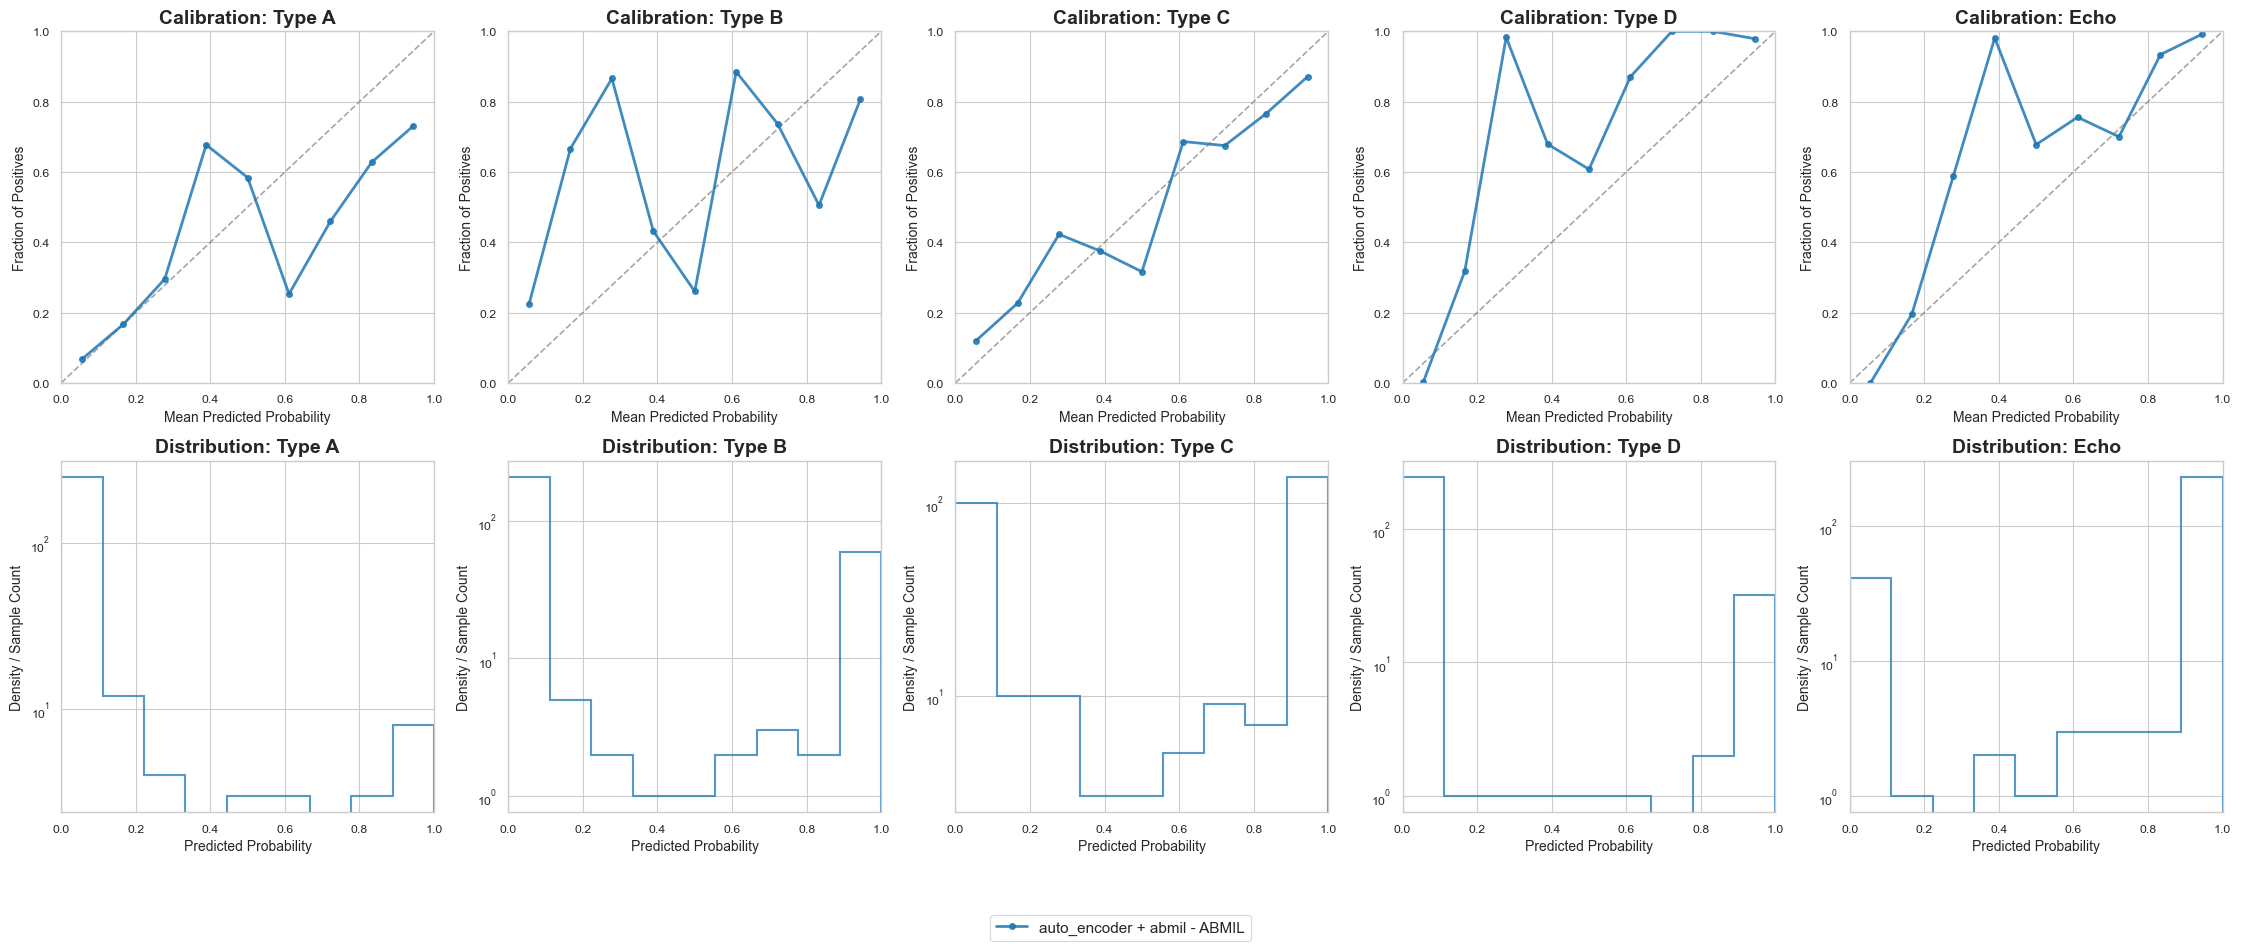

In [70]:
pipeline = {
    'auto_encoder + abmil' : autoencoder_results,
}
plot_comprehensive_calibration(
    encoder_results=pipeline, 
    label_names=label_names, 
    n_bins=10, 
    strategy="uniform"
)

In [71]:
#Use Asymetric loss
results2 = abmil_classifier_tuned(X_bags_enhanced, y_new, n_split_out=5,n_split_in=3, num_trials=1,random_state=42,n_iter_search = 3)

Starting Trial 1/1 with random_state=42...
  Tuning and evaluating model: ABMIL
    Evaluating fold 1/5
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Early stopping at epoch 27
[CV 1/3] END attention_dim=128, dropout=0.1, hidden_dim=256, learning_rate=0.0017524101118128151, weight_decay=0.0002481040974867811;, score=nan total time=  25.5s
Early stopping at epoch 14
[CV 2/3] END attention_dim=128, dropout=0.1, hidden_dim=256, learning_rate=0.0017524101118128151, weight_decay=0.0002481040974867811;, score=nan total time=  13.1s
Early stopping at epoch 16
[CV 3/3] END attention_dim=128, dropout=0.1, hidden_dim=256, learning_rate=0.0017524101118128151, weight_decay=0.0002481040974867811;, score=nan total time=  15.1s
[CV 1/3] END attention_dim=128, dropout=0.3, hidden_dim=256, learning_rate=0.00014786125334132768, weight_decay=6.870614282613295e-05;, score=nan total time=  37.4s
Early stopping at epoch 31
[CV 2/3] END attention_dim=128, dropout=0.3, hidden_dim=256, learning_ra

In [72]:
autoencoder_results2 = results2

In [73]:
from tabulate import tabulate
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']
autoencoder_results_compiled2 = compile_results(autoencoder_results2,label_names=label_names,encoder="")
df = pd.DataFrame(generate_metrics_table2(autoencoder_results_compiled2,label_names=label_names)[0])
print(tabulate(df, headers='keys', tablefmt='psql'))

+----+---------+---------------+-------------------+-----------------+---------------+
|    | Model   | Macro-AUC     | Macro-AP (cmAP)   | Brier Score ↓   | Log-Loss ↓    |
|----+---------+---------------+-------------------+-----------------+---------------|
|  0 | ABMIL   | 0.879 ± 0.000 | 0.816 ± 0.000     | 0.050 ± 0.000   | 0.322 ± 0.000 |
+----+---------+---------------+-------------------+-----------------+---------------+


In [74]:
df2 = pd.DataFrame(generate_metrics_table2(autoencoder_results_compiled2,label_names=label_names)[1])
print(tabulate(df2, headers='keys', tablefmt='psql'))

+----+---------+---------------+---------------+---------------+---------------+---------------+
|    | Model   | Type A AP     | Type B AP     | Type C AP     | Type D AP     | Echo AP       |
|----+---------+---------------+---------------+---------------+---------------+---------------|
|  0 | ABMIL   | 0.272 ± 0.000 | 0.955 ± 0.000 | 0.897 ± 0.000 | 0.974 ± 0.000 | 0.980 ± 0.000 |
+----+---------+---------------+---------------+---------------+---------------+---------------+


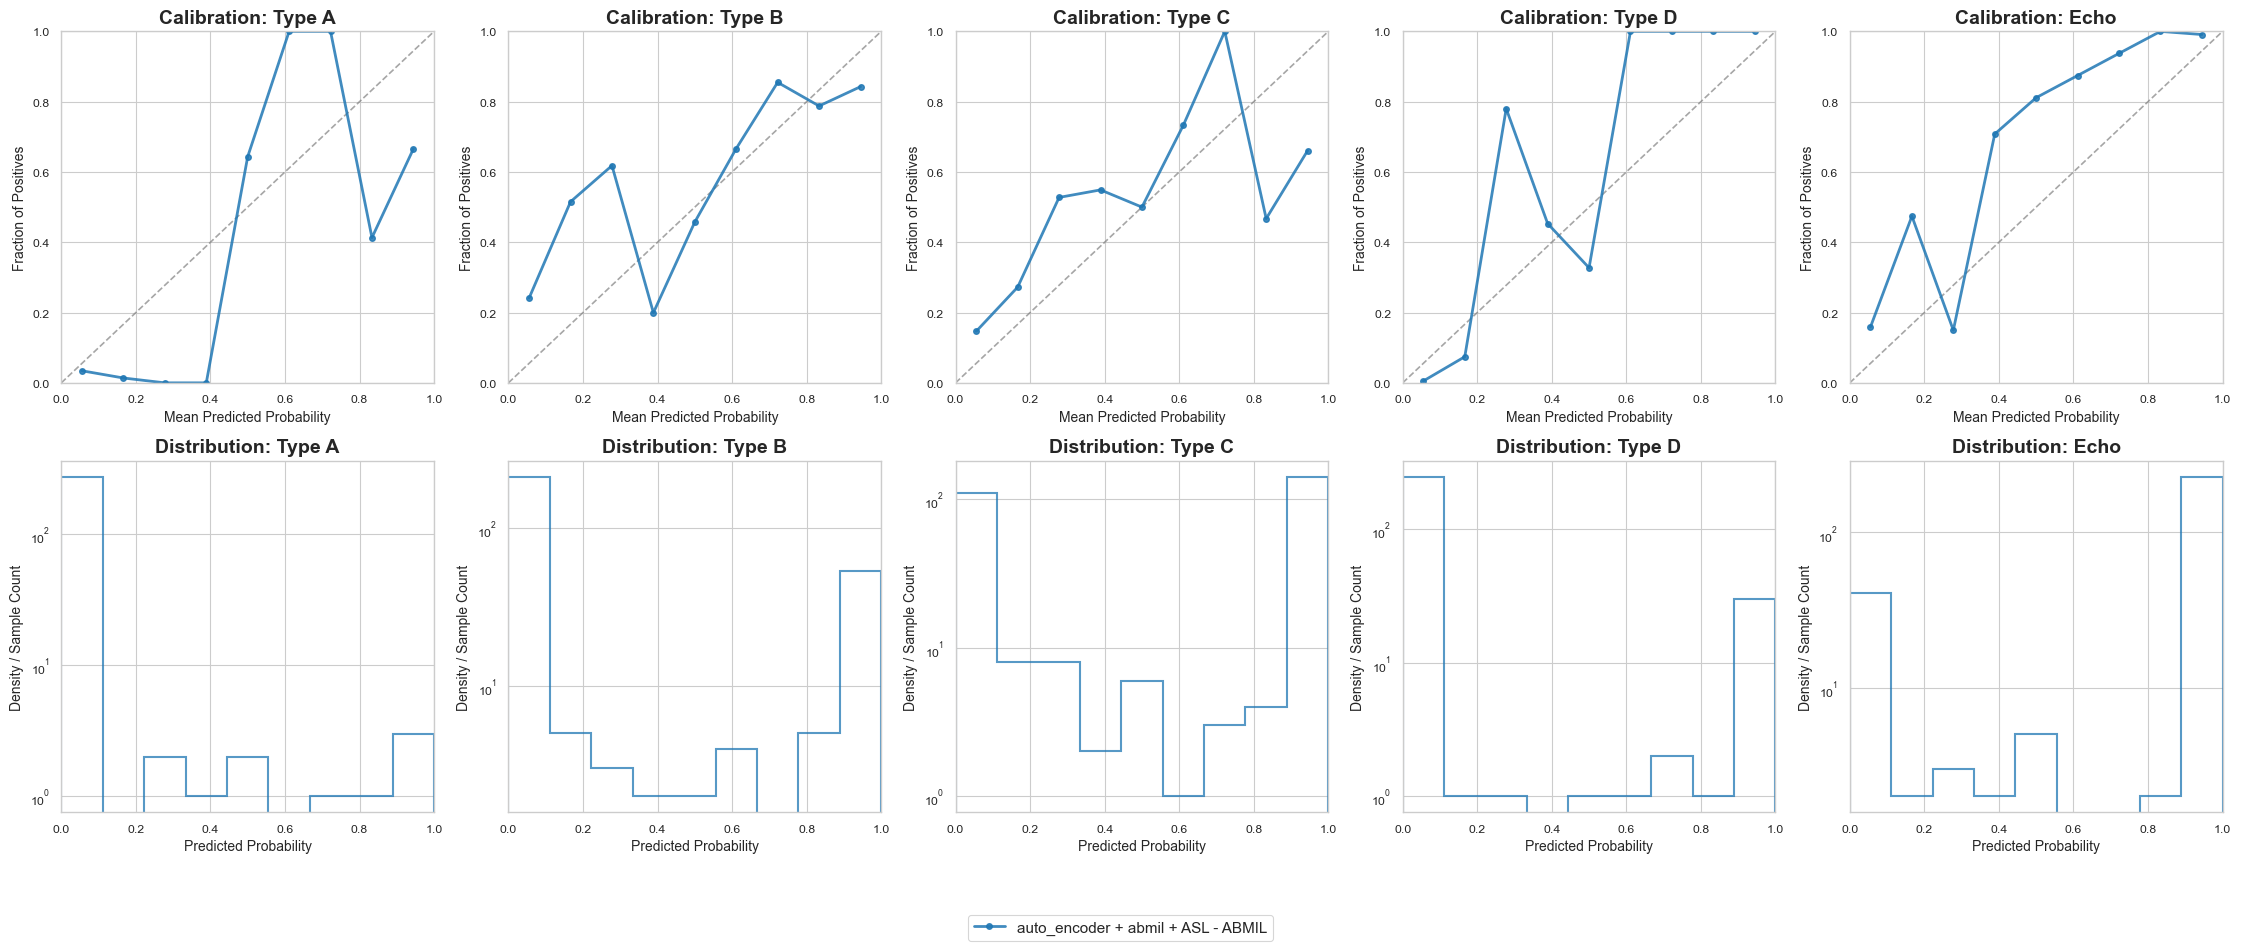

In [82]:
pipeline = {
    'auto_encoder + abmil + ASL' : autoencoder_results2,
}
plot_comprehensive_calibration(
    encoder_results=pipeline, 
    label_names=label_names, 
    n_bins=10, 
    strategy="uniform"
)

In [ ]:
autoencoder_results2[0]['oof_y_true']

array([[3.93874070e-05, 1.67141889e-06, 1.43298195e-07, 4.79032547e-04,
        9.99911547e-01],
       [5.27039694e-04, 4.73110063e-04, 6.94402770e-05, 1.69895226e-04,
        9.99352038e-01],
       [1.64192869e-07, 9.66932703e-08, 9.73614078e-07, 1.12869684e-05,
        9.93016839e-01],
       ...,
       [3.97962658e-03, 8.67377128e-03, 4.29120194e-03, 9.93804216e-01,
        9.91964102e-01],
       [1.07826805e-02, 3.15545090e-02, 1.28987255e-02, 9.59134758e-01,
        9.91501212e-01],
       [4.15514270e-03, 3.07814218e-02, 9.67830598e-01, 4.61663352e-03,
        9.98582959e-01]], shape=(284, 5), dtype=float32)

In [81]:
type_a_indices = np.where(autoencoder_results2[0]['oof_y_true'][:, 0] == 1)[0]
print(autoencoder_results2[0]['oof_y_true'][type_a_indices])
print(autoencoder_results2[0]['oof_y_pred_proba'][type_a_indices])

[[1. 1. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 0. 1. 0. 1.]
 [1. 0. 1. 0. 0.]
 [1. 0. 1. 0. 1.]
 [1. 1. 1. 0. 0.]
 [1. 1. 0. 0. 0.]]
[[4.2117936e-06 9.9994540e-01 9.9999511e-01 1.2189876e-08 9.3444669e-07]
 [5.8280206e-05 9.9331611e-01 2.9195797e-02 8.8819423e-09 6.6812783e-05]
 [8.8604878e-07 9.9989760e-01 1.9362058e-02 8.1155868e-06 8.7251428e-06]
 [3.3926293e-07 3.4914609e-07 6.8967795e-04 2.5804057e-03 2.6409963e-01]
 [9.7699100e-01 9.9984980e-01 9.6970424e-02 5.4834130e-05 1.8380540e-05]
 [7.7425897e-01 9.9955851e-01 3.3234198e-02 1.1303514e-05 1.2381251e-04]
 [9.3004483e-01 4.4145927e-04 1.0730338e-03 3.6485866e-04 2.2607753e-02]
 [3.8735612e-05 9.9999166e-01 2.2785542e-05 1.4632087e-06 1.1339381e-05]
 [1.2041323e-05 9.9999988e-01 2.6672237e-02 1.2728143e-06 9.9998772e-01]
 [1.9141883e-06 6.6916295e-04 3.0780531e-09 4.2372207e

In [79]:

label_confusion(autoencoder_results2[0]['oof_y_true'],autoencoder_results2[0]['oof_y_pred_proba'],y_pred_binary=None, label_names=label_names, threshold=0.5) 

,Type A,Type B,Type C,Type D,Echo
Type A,0.0,3.0,0.0,0.0,0.0
Type B,0.0,0.0,4.0,0.0,0.0
Type C,0.0,1.0,0.0,0.0,0.0
Type D,0.0,0.0,1.0,0.0,0.0
Echo,0.0,0.0,1.0,0.0,0.0
